# Final Project
## Predict the Likelihood of Loan Default

>Darren Levreault    
901510003  
d.levreault0003@student.nu.edu  
ANA 615

In [92]:
#Loading phase
from pathlib import Path
import math

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.metrics import accuracy_score

import matplotlib.pylab as plt

from dmba import classificationSummary
from dmba import AIC_score
from dmba import backward_elimination, forward_selection, stepwise_selection

%matplotlib inline

%matplotlib inline
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from pathlib import Path
from sklearn.metrics import roc_auc_score
import seaborn as sns
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.metrics import recall_score
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
import matplotlib.pylab as plt
import dmba
from dmba import plotDecisionTree, classificationSummary, regressionSummary

In [62]:
import os
os.chdir("/Users/levreault/Documents/Projects/ANA 615/dmba")
os.getcwd()

'/Users/levreault/Documents/Projects/ANA 615/dmba'

In [63]:
# Load dataset
df_lend = pd.read_csv("lending_club.csv")
df_lend.rename(columns={"Unnamed: 0": "loan_id"}, inplace=True)
# Preview
df_lend.head(10)

,loan_id,loan_status,annual_inc,dti,delinq_2yrs,fico_range_low,fico_range_high,inq_last_6mths,mths_since_last_delinq,open_acc,revol_bal,revol_util,total_acc
0,133423,Fully Paid,125000.0,20.81,0.0,675.0,679.0,0.0,24.0,15.0,23337.0,58.9,23.0
1,557225,Late (31-120 days),23500.0,23.95,0.0,665.0,669.0,0.0,33.0,5.0,4009.0,35.5,11.0
2,80694,Current,63000.0,8.72,0.0,745.0,749.0,1.0,NaN,6.0,3045.0,20.7,10.0
3,651321,Fully Paid,40000.0,31.09,1.0,680.0,684.0,1.0,13.0,14.0,24950.0,53.8,26.0
4,150555,Current,90000.0,19.72,1.0,705.0,709.0,3.0,5.0,12.0,12729.0,23.2,26.0
5,250451,Fully Paid,120000.0,10.53,0.0,660.0,664.0,3.0,42.0,8.0,5901.0,59.6,34.0
6,294712,Fully Paid,225000.0,9.03,0.0,665.0,669.0,4.0,NaN,10.0,542.0,6.8,30.0
7,315908,Fully Paid,94000.0,15.33,0.0,660.0,664.0,3.0,66.0,12.0,6125.0,49.0,30.0
8,649396,Current,80000.0,22.29,0.0,695.0,699.0,1.0,NaN,19.0,29645.0,82.3,36.0
9,1028995,Fully Paid,46000.0,29.32,2.0,665.0,669.0,1.0,18.0,8.0,4287.0,80.9,16.0


In [64]:
df_lend.shape

(104858, 13)

In [65]:
df_lend.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104858 entries, 0 to 104857
Data columns (total 13 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   loan_id                 104858 non-null  int64  
 1   loan_status             104855 non-null  object 
 2   annual_inc              104855 non-null  float64
 3   dti                     104774 non-null  float64
 4   delinq_2yrs             104855 non-null  float64
 5   fico_range_low          104855 non-null  float64
 6   fico_range_high         104855 non-null  float64
 7   inq_last_6mths          104855 non-null  float64
 8   mths_since_last_delinq  52258 non-null   float64
 9   open_acc                104855 non-null  float64
 10  revol_bal               104855 non-null  float64
 11  revol_util              104776 non-null  float64
 12  total_acc               104855 non-null  float64
dtypes: float64(11), int64(1), object(1)
memory usage: 10.4+ MB


In [66]:
df_lend.columns

Index(['loan_id', 'loan_status', 'annual_inc', 'dti', 'delinq_2yrs',
       'fico_range_low', 'fico_range_high', 'inq_last_6mths',
       'mths_since_last_delinq', 'open_acc', 'revol_bal', 'revol_util',
       'total_acc'],
      dtype='object')

## EDA

In [67]:
#only num
num_cols = df_lend.select_dtypes(include=['int64', 'float64'])

#correlation matrix
corr_matrix = num_cols.corr()

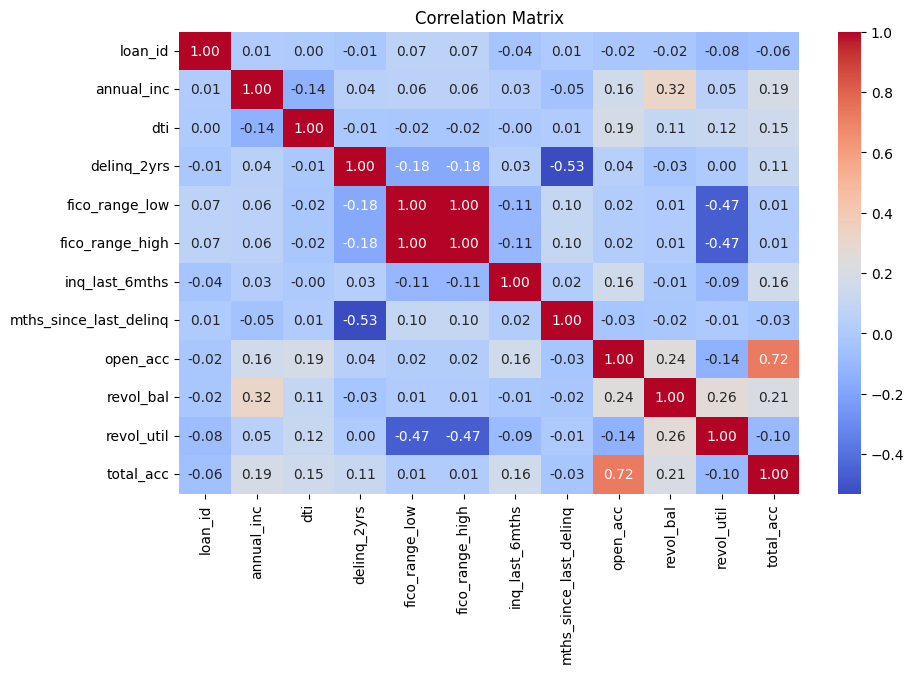

In [68]:
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [69]:
# Check for missing data %
missing_pct = df_lend.isnull().mean() * 100
missing_pct.sort_values(ascending=False)

mths_since_last_delinq    50.163078
dti                        0.080108
revol_util                 0.078201
loan_status                0.002861
annual_inc                 0.002861
delinq_2yrs                0.002861
fico_range_low             0.002861
fico_range_high            0.002861
inq_last_6mths             0.002861
open_acc                   0.002861
revol_bal                  0.002861
total_acc                  0.002861
loan_id                    0.000000
dtype: float64

In [70]:
#Missing data (num)
df_lend.isnull().sum()

loan_id                       0
loan_status                   3
annual_inc                    3
dti                          84
delinq_2yrs                   3
fico_range_low                3
fico_range_high               3
inq_last_6mths                3
mths_since_last_delinq    52600
open_acc                      3
revol_bal                     3
revol_util                   82
total_acc                     3
dtype: int64

For Dimension reduction, fico_range_low & fico_range_high have high cor=1. As seen in Corr Matrix.  
For this, I will add both together and divide by two, this will result in creation of "fico_avg".


In [71]:
#Create Fico_avg
df_lend["fico_avg"] = (df_lend["fico_range_low"] + df_lend["fico_range_high"]) / 2


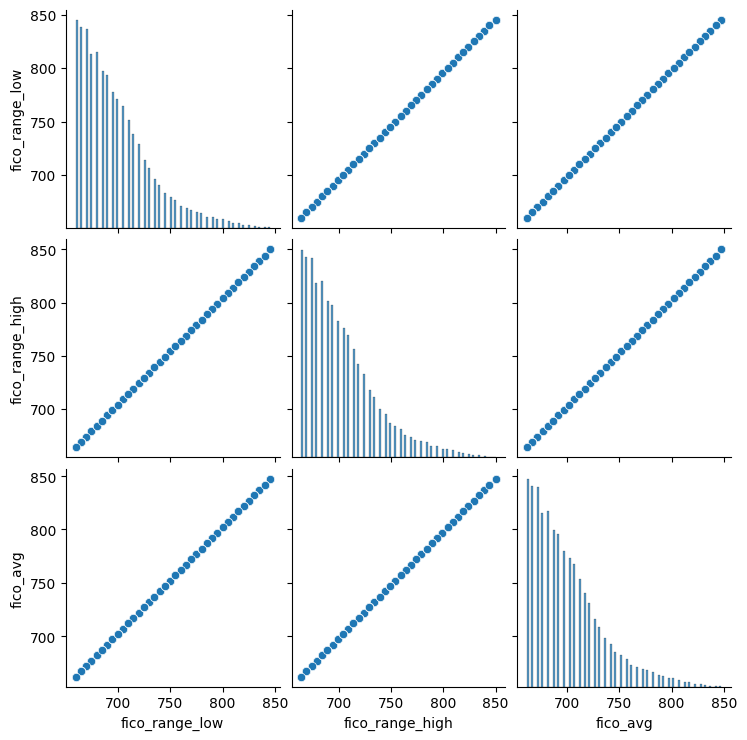

In [72]:
#Using a Pairplot to check if fico_avg is okay to replace fico_low& high
sns.pairplot(df_lend[["fico_range_low", "fico_range_high", "fico_avg"]])
plt.show()

In [73]:
#Remove fico_low & fico high
df_lend = df_lend.drop(columns=["fico_range_low", "fico_range_high"])

### Fix missing data

In [74]:
# For mths_since_last_delinq, ~50% "missing" Create indicator 
df_lend["no_delinq"] = df_lend["mths_since_last_delinq"].isnull().astype(int)

# Fill missing with a large value = "never delinquent"
df_lend["mths_since_last_delinq"] = df_lend["mths_since_last_delinq"].fillna(999)

In [75]:
# For dti & revol_util , Median will be used to impute
df_lend["dti"] = df_lend["dti"].fillna(df_lend["dti"].median())
df_lend["revol_util"] = df_lend["revol_util"].fillna(df_lend["revol_util"].median())

In [76]:
# for remaining missing values we will also fill with median
df_lend.fillna(df_lend.median(numeric_only=True), inplace=True)

In [77]:
# For loan_status , missing values will be removed, only ~.003% of data. 
df_lend = df_lend.dropna(subset=["loan_status"])

In [78]:
#check for missing
df_lend.isnull().sum()

loan_id                   0
loan_status               0
annual_inc                0
dti                       0
delinq_2yrs               0
inq_last_6mths            0
mths_since_last_delinq    0
open_acc                  0
revol_bal                 0
revol_util                0
total_acc                 0
fico_avg                  0
no_delinq                 0
dtype: int64

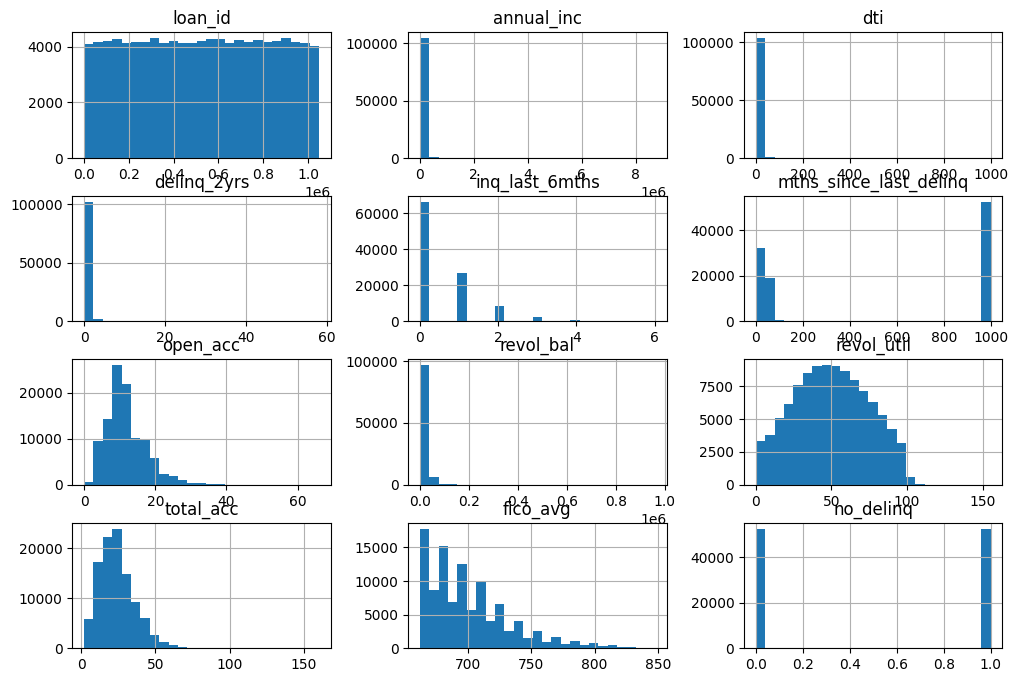

In [79]:
#Distro check w/ histograms 
df_lend.hist(bins=25, figsize=(12,8))
plt.show()

In [80]:
#multicollinearity check
corr = df_lend.corr(numeric_only=True)
corr[(corr > 0.8) & (corr < 1.0)]

,loan_id,annual_inc,dti,delinq_2yrs,inq_last_6mths,mths_since_last_delinq,open_acc,revol_bal,revol_util,total_acc,fico_avg,no_delinq
loan_id,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
annual_inc,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dti,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
delinq_2yrs,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
inq_last_6mths,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mths_since_last_delinq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.999483
open_acc,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
revol_bal,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
revol_util,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
total_acc,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [81]:
df_lend.dtypes

loan_id                     int64
loan_status                object
annual_inc                float64
dti                       float64
delinq_2yrs               float64
inq_last_6mths            float64
mths_since_last_delinq    float64
open_acc                  float64
revol_bal                 float64
revol_util                float64
total_acc                 float64
fico_avg                  float64
no_delinq                   int64
dtype: object

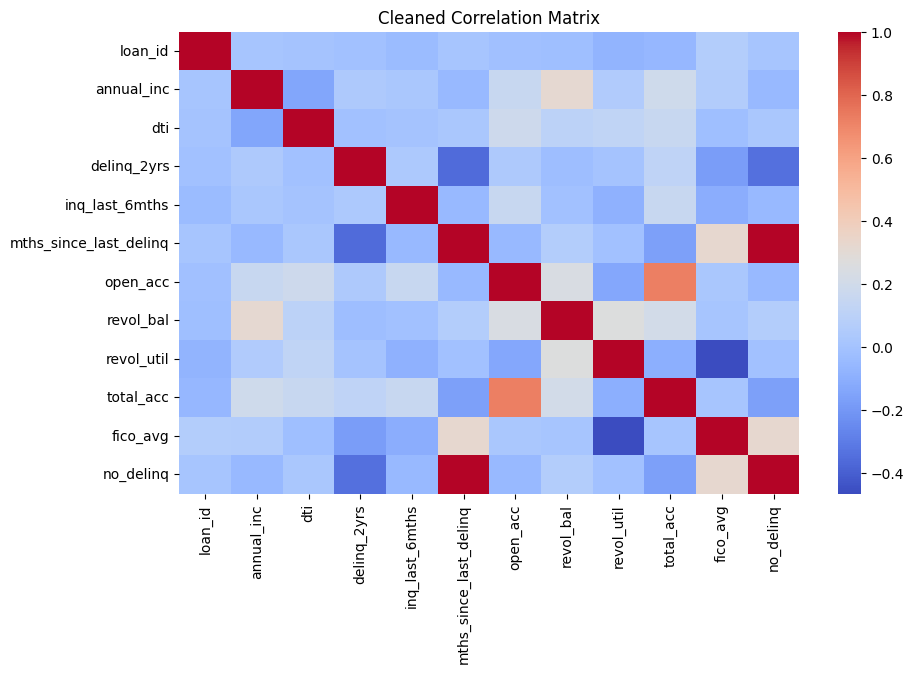

In [82]:
#Cor matrix check for cleaned data
corr = df_lend.corr(numeric_only=True)

plt.figure(figsize=(10,6))
sns.heatmap(corr, cmap="coolwarm")
plt.title("Cleaned Correlation Matrix")
plt.show()

In [83]:
df_lend.describe

<bound method NDFrame.describe of         loan_id         loan_status  annual_inc    dti  delinq_2yrs  \
0        133423          Fully Paid    125000.0  20.81          0.0   
1        557225  Late (31-120 days)     23500.0  23.95          0.0   
2         80694             Current     63000.0   8.72          0.0   
3        651321          Fully Paid     40000.0  31.09          1.0   
4        150555             Current     90000.0  19.72          1.0   
...         ...                 ...         ...    ...          ...   
104853   545353             Current    120000.0  13.27          1.0   
104854   906734          Fully Paid     47000.0  26.92          1.0   
104855   796286             Current     67000.0   2.24          0.0   
104856   954087          Fully Paid    100000.0  15.23          0.0   
104857   189199          Fully Paid     50000.0  28.95          0.0   

        inq_last_6mths  mths_since_last_delinq  open_acc  revol_bal  \
0                  0.0                    

In [84]:
#Save cleaned data sheet
#df_lend.to_csv("df_lend_clean.csv", index=False)

## Begin Part 2

### Create Target 

From loan_status variable, where charge-off=1 and all others are equal to 0.


In [85]:
df_lend["default"] = np.where(df_lend["loan_status"] == "Charged Off", 1, 0)
print(df_lend)

        loan_id         loan_status  annual_inc    dti  delinq_2yrs  \
0        133423          Fully Paid    125000.0  20.81          0.0   
1        557225  Late (31-120 days)     23500.0  23.95          0.0   
2         80694             Current     63000.0   8.72          0.0   
3        651321          Fully Paid     40000.0  31.09          1.0   
4        150555             Current     90000.0  19.72          1.0   
...         ...                 ...         ...    ...          ...   
104853   545353             Current    120000.0  13.27          1.0   
104854   906734          Fully Paid     47000.0  26.92          1.0   
104855   796286             Current     67000.0   2.24          0.0   
104856   954087          Fully Paid    100000.0  15.23          0.0   
104857   189199          Fully Paid     50000.0  28.95          0.0   

        inq_last_6mths  mths_since_last_delinq  open_acc  revol_bal  \
0                  0.0                    24.0      15.0    23337.0   
1    

In [86]:
df_lend[["loan_status", "default"]].value_counts()

loan_status         default
Fully Paid          0          48162
Current             0          42122
Charged Off         1          12851
Late (31-120 days)  0           1080
In Grace Period     0            418
Late (16-30 days)   0            220
Default             0              2
Name: count, dtype: int64

In [87]:
X = df_lend.drop(columns=["loan_status", "default", "loan_id"])
y = df_lend["default"]

In [88]:
#Train/test split 
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.30, 
    random_state=52,
    stratify=y
)

In [89]:
# DecisionTree 
dt_model = DecisionTreeClassifier(
    max_depth=10,
    min_samples_leaf=5,
    min_samples_split=10,
    class_weight="balanced",
    random_state=42
)

dt_model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [90]:
print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])
print("Number of predictors:", X_train.shape[1])

Training rows: 73398
Testing rows: 31457
Number of predictors: 11


In [93]:
# Confusion Matrix / Accuracy 
y_pred = dt_model.predict(X_test)
y_prob = dt_model.predict_proba(X_test)[:, 1]
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

cm = confusion_matrix(y_test, y_pred)

cm_df = pd.DataFrame(
    cm,
    index=["Actual 0", "Actual 1"],
    columns=["Predicted 0", "Predicted 1"]
)

cm_df

Accuracy: 0.588231554185078


,Predicted 0,Predicted 1
Actual 0,16278,11324
Actual 1,1629,2226


### ROC 

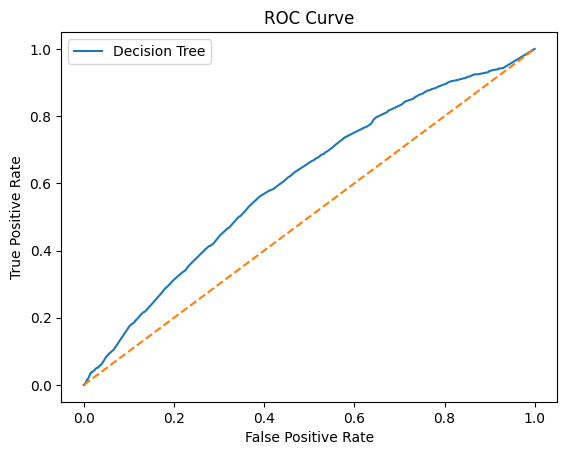

In [94]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr, label="Decision Tree")
plt.plot([0, 1], [0, 1], linestyle="--")  
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

### AUC 

In [95]:
auc = roc_auc_score(y_test, y_prob)
print("AUC:", auc)

AUC: 0.6066070467458936


In [96]:
import pandas as pd

importance = pd.Series(
    dt_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

importance

fico_avg                  0.283552
dti                       0.192743
revol_bal                 0.106621
annual_inc                0.097931
revol_util                0.082497
inq_last_6mths            0.078015
total_acc                 0.076034
mths_since_last_delinq    0.044542
open_acc                  0.034514
delinq_2yrs               0.002377
no_delinq                 0.001175
dtype: float64

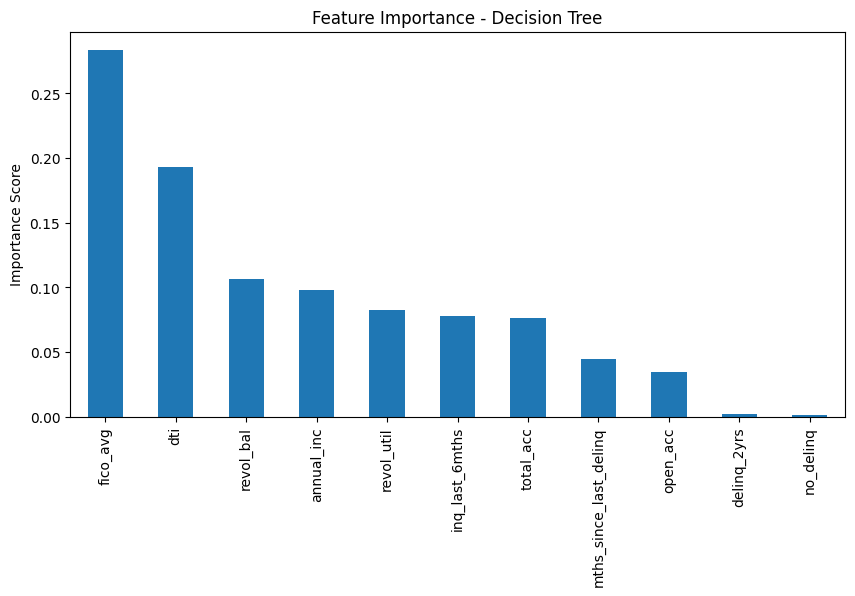

In [97]:
import matplotlib.pyplot as plt

importance.plot(kind="bar", figsize=(10,5))
plt.title("Feature Importance - Decision Tree")
plt.ylabel("Importance Score")
plt.show()

### Lift

In [98]:
lift_df = pd.DataFrame({
    "actual": y_test,
    "prob": y_prob
})

In [99]:
lift_df = lift_df.sort_values(by="prob", ascending=False)

In [100]:
lift_df["decile"] = pd.qcut(lift_df["prob"], 10, labels=False)

lift_table = lift_df.groupby("decile").agg(
    total=("actual", "count"),
    defaults=("actual", "sum")
)

lift_table["default_rate"] = lift_table["defaults"] / lift_table["total"]


overall_rate = lift_df["actual"].mean()

lift_table["lift"] = lift_table["default_rate"] / overall_rate

lift_table = lift_table.sort_index(ascending=False)

lift_table

,total,defaults,default_rate,lift
decile,,,,
9,2236,405,0.181127,1.478006
8,3965,716,0.180580,1.473543
7,3176,480,0.151134,1.233257
6,2745,441,0.160656,1.310959
5,3207,396,0.123480,1.007602
4,3516,405,0.115188,0.939938
3,2918,301,0.103153,0.841733
2,3285,274,0.083409,0.680625
1,2688,148,0.055060,0.449289


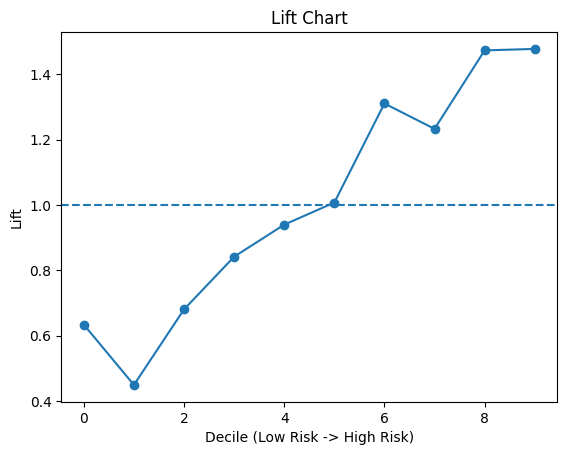

In [101]:
#plot lift

plt.plot(lift_table.index, lift_table["lift"], marker="o")
plt.axhline(1, linestyle="--")  # baseline
plt.title("Lift Chart")
plt.xlabel("Decile (Low Risk -> High Risk)")
plt.ylabel("Lift")
plt.show()

### Random Forrest 

In [102]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [103]:
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

In [104]:
#CONFUSION MATRIX
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print("RF Accuracy:", accuracy_rf)

cm_rf = confusion_matrix(y_test, y_pred_rf)

cm_rf_df = pd.DataFrame(
    cm_rf,
    index=["Actual 0", "Actual 1"],
    columns=["Predicted 0", "Predicted 1"]
)

cm_rf_df

RF Accuracy: 0.6637314429220841


,Predicted 0,Predicted 1
Actual 0,18909,8693
Actual 1,1885,1970


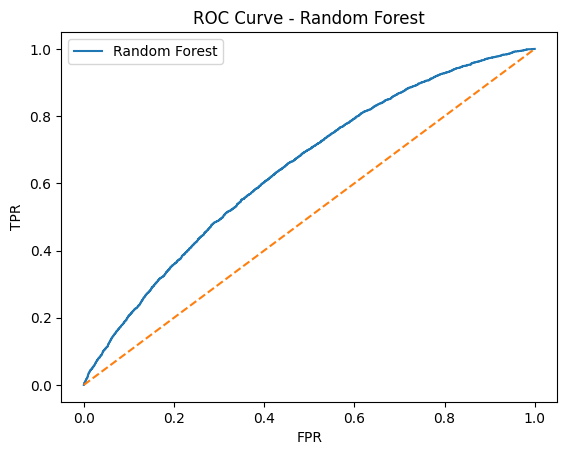

RF AUC: 0.6443028386352574


In [105]:
#ROC & AUC
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.plot(fpr_rf, tpr_rf, label="Random Forest")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("ROC Curve - Random Forest")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.legend()
plt.show()

print("RF AUC:", roc_auc_score(y_test, y_prob_rf))

In [106]:
importance_rf = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

importance_rf

fico_avg                  0.233937
dti                       0.158485
revol_bal                 0.114743
annual_inc                0.112783
revol_util                0.108028
inq_last_6mths            0.079729
total_acc                 0.068935
open_acc                  0.056137
mths_since_last_delinq    0.049157
delinq_2yrs               0.012445
no_delinq                 0.005622
dtype: float64

In [107]:
# LIFT
lift_df_rf = pd.DataFrame({
    "actual": y_test,
    "prob": y_prob_rf
}).sort_values(by="prob", ascending=False)

lift_df_rf["decile"] = pd.qcut(lift_df_rf["prob"], 10, labels=False)



lift_table_rf = lift_df_rf.groupby("decile").agg(
    total=("actual", "count"),
    defaults=("actual", "sum")
)

lift_table_rf["default_rate"] = lift_table_rf["defaults"] / lift_table_rf["total"]
overall_rate = lift_df_rf["actual"].mean()
lift_table_rf["lift"] = lift_table_rf["default_rate"] / overall_rate

lift_table_rf

,total,defaults,default_rate,lift
decile,,,,
0,3146,119,0.037826,0.308661
1,3146,189,0.060076,0.490226
2,3145,267,0.084897,0.692761
3,3146,309,0.098220,0.801480
4,3146,358,0.113795,0.928576
5,3145,392,0.124642,1.017088
6,3146,430,0.136682,1.115328
7,3145,511,0.162480,1.325846
8,3146,570,0.181182,1.478458


## DF vs RF Lift chart

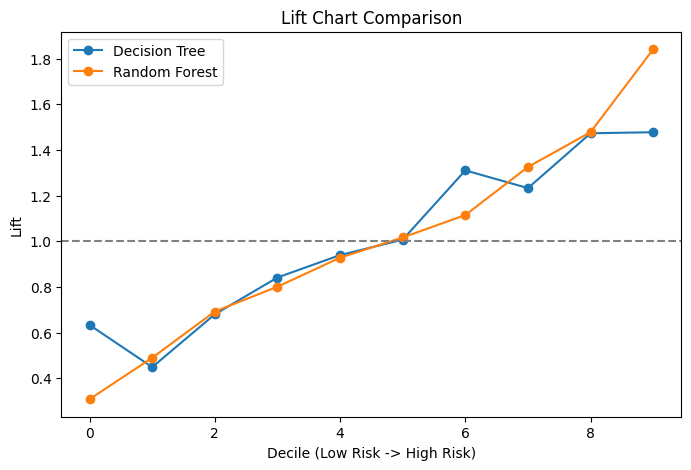

In [108]:
plt.figure(figsize=(8,5))

plt.plot(lift_table.index, lift_table["lift"], marker="o", label="Decision Tree")
plt.plot(lift_table_rf.index, lift_table_rf["lift"], marker="o", label="Random Forest")

plt.axhline(1, linestyle="--", color="gray")

plt.title("Lift Chart Comparison")
plt.xlabel("Decile (Low Risk -> High Risk)")
plt.ylabel("Lift")
plt.legend()

plt.show()

In [109]:
#precision, recall, F1
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.91      0.69      0.78     27602
           1       0.18      0.51      0.27      3855

    accuracy                           0.66     31457
   macro avg       0.55      0.60      0.53     31457
weighted avg       0.82      0.66      0.72     31457



In [110]:
#Imbalance check
y.value_counts(normalize=True)

default
0    0.87744
1    0.12256
Name: proportion, dtype: float64

In [116]:
#Adding a Threshold 
# Create threshold predictions
threshold = 0.4
y_pred_thresh = (y_prob_rf >= threshold).astype(int)

cm_thresh = confusion_matrix(y_test, y_pred_thresh)

cm_thresh_df = pd.DataFrame(
    cm_thresh,
    index=["Actual 0", "Actual 1"],
    columns=["Predicted 0", "Predicted 1"]
)

cm_thresh_df

,Predicted 0,Predicted 1
Actual 0,10745,16857
Actual 1,762,3093


In [117]:
recall_05 = recall_score(y_test, y_pred_rf)
print("Recall (threshold=0.5):", recall_05)

Recall (threshold=0.5): 0.5110246433203631


In [118]:
recall_04 = recall_score(y_test, y_pred_thresh)
print("Recall (threshold=0.4):", recall_04)

Recall (threshold=0.4): 0.8023346303501946


## Write-Up

### Objective
The objective of this project is to develop a predictive model to estimate the likelihood of loan default using a dataset from Lending Club. The analysis focuses on building and evaluating classification models, while ensuring proper data preparation, avoiding target leakage, and interpreting model performance in a meaningful way.

### Data Cleaning and Feature Engineering
The following preprocessing steps were applied:  
>Removed identifier variable (loan_id) to prevent artificial patterns  
Verified no post-loan (“future”) variables were included to avoid target leakage  
Handled missing values appropriately (noted in code blocks)  
Created new features:  
fico_avg: average of FICO score range  
no_delinq: indicator for no delinquency history  

The dataset did not include a predefined target variable. Therefore, a binary target variable (default) was created from the loan_status field:  
1 = Charged Off (default)  
0 = All other statuses

The dataset was divided into training and testing sets:
>70% Training  
30% Testing  
Stratified sampling was used to preserve class distribution  
The dataset is imbalanced:  
Non-default: ~87.7%  
Default: ~12.3%

### Modeling Approach
A Decision Tree was first developed as a baseline model, followed by a Random Forest to improve predictive performance.  
>Decision Tree:  
Accuracy ≈ 0.59  
AUC ≈ 0.60
 
>Random Forest (final model):  
Accuracy ≈ 0.66  
AUC ≈ 0.64  
The Random Forest outperformed the decision tree by better capturing complex relationships and reducing variance.

### Model Performance
>Classification Performance (Random Forest)  
Recall (default): ~51%  
Precision (default): ~18%  
The model identifies approximately half of default cases but generates a relatively high number of false positives. This trade-off is expected in imbalanced classification problems.  

>Lift and Ranking Ability  
The Random Forest model demonstrates strong ranking capability:  
Top decile lift ≈ 1.85  
Decision Tree lift ≈ 1.48  
This indicates the model is significantly more effective than random selection in identifying high-risk borrowers.  

>Threshold Analysis  
Lowering the classification threshold from 0.5 to 0.4 increased recall from ~51% to ~80%, improving detection of default cases. However, this also increased false positives. This demonstrates the importance of threshold selection based on business objectives. In a financial context, this trade-off may be acceptable, as missing a default (false negative) can be more costly than incorrectly flagging a non-default loan (false positive).

### Key Drivers of Default Risk
The most important predictors were:  
>Credit score (fico_avg)  
Debt-to-income ratio (dti)  
Revolving balance and utilization  
Annual income
  
These variables align with financial risk theory, confirming that higher debt burden and lower credit quality increase default risk.

### Recommendations
>Model Selection: Use the Random Forest model for better predictive performance and ranking ability.  
Threshold Strategy: Consider using a threshold below 0.5 to prioritize identifying high-risk loans.  
Business Application: Focus on top-risk segments identified by lift for targeted risk mitigation.  
Future Improvements: Incorporate additional behavioral data and explore more advanced models to improve performance.  

### Limitation
The model shows moderate performance (AUC ~0.64), indicating limited predictive power.  
Improvement:  
Additional variables (e.g., payment history, behavioral data) or more advanced models could improve performance.

### Conclusion
This analysis developed and evaluated predictive models to estimate loan default risk using Lending Club data. The Random Forest model outperformed the decision tree, achieving an AUC of approximately 0.64 and demonstrating improved ability to rank borrowers by risk, as confirmed by lift analysis.  
While overall predictive power is moderate, the model consistently identifies meaningful patterns related to credit quality and financial burden, such as FICO score and debt-to-income ratio. Importantly, the results highlight the impact of class imbalance and the limitations of accuracy as a standalone metric. Adjusting the classification threshold significantly improved default detection, reinforcing the importance of aligning model outputs with business objectives.  
Although the model does not provide highly accurate predictions at the individual level, it is effective for risk segmentation and prioritization, enabling lenders to focus on higher risk borrowers. The relatively modest AUC suggests that model performance is constrained by the available features rather than the modeling approach itself. Future improvements would likely require richer behavioral or transactional data.  
Overall, this analysis demonstrates a complete and realistic modeling workflow, emphasizing proper data handling, avoidance of target leakage, appropriate evaluation for imbalanced data, and practical application of predictive modeling in a financial risk context.